# Counting Molecules — Stage 1: Reading and Standardising STM Images

This notebook ingests raw Scanning Tunnelling Microscopy (STM) images from three different file formats (`.txt`, `.p`, `.sxm`), standardises them into a common NumPy array representation, and applies preprocessing to remove the mean-field gradient artefact that's characteristic of STM scans.

The output of this stage feeds directly into the binarisation step in `02_binarization.ipynb`.

**Author:** Stephanie Wainaina  
**Project type:** Monash data science studio  
**Stack:** Python, NumPy, scikit-image, nanonispy, Matplotlib

> See the repo README for full project context. Data files are not included in this repository (proprietary research data), so cell outputs are saved for reference.

---

## What this notebook does

1. Loads STM images from three different file formats
2. Wraps each loader in a function for reuse downstream
3. Removes the mean-field gradient that's typical of STM imaging
4. Saves a standardised representation for the next stage of the pipeline

## 1. Setup

The three datasets are stored in subfolders of `data/raw_images/`. The folder structure is:

```
data/raw_images/
├── dataset_a/    # .txt format scans
├── dataset_b/    # pickled .p files containing image + rescale metadata
└── dataset_c/    # Nanonis .sxm scan files
```

If you're running this notebook locally, point `DATA_DIR` to wherever you've placed the data.

In [1]:
pip install nanonispy

Note: you may need to restart the kernel to use updated packages.


In [32]:
import numpy as np
np.int= int

In [15]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import nanonispy as nap

# Path to the data folder. Edit this if your data lives elsewhere.

DATA_DIR = r'C:\Users\steph\OneDrive\Desktop\github_rebuild\counting_molecules\Counting-Molecules\data'

In [18]:
if not hasattr(np, "float"):
    np.float = float

## 2. Three file formats, three loaders

Each STM dataset comes in a different format. Rather than copy-pasting loading code throughout the pipeline, each format gets a dedicated loader function that returns a standardised 2D NumPy array.

In [35]:
def load_txt_image(filepath):
    """Load an STM image stored as a plain text array.
    
    Parameters
    ----------
    filepath : str
        Path to the .txt file containing the image data.
    
    Returns
    -------
    np.ndarray
        2D image array.
    """
    return np.loadtxt(filepath)


def load_pickle_image(filepath):
    """Load an STM image from a pickled dictionary.
    
    The pickle is expected to contain a dict with at least an 'image' key,
    and optionally a 'rescale' key for converting pixels to real-space distances.
    
    Parameters
    ----------
    filepath : str
        Path to the .p file.
    
    Returns
    -------
    tuple of (np.ndarray, float or None)
        The image array and the rescale factor (None if not present).
    """
    
    with open(filepath, "rb") as f:
        data = pickle.load(f)
    image = data["image"]
    rescale = data.get("rescale", None)
    return image, rescale


def load_sxm_image(filepath):
    """Load an STM image from a Nanonis .sxm scan file.
    
    Handles scan direction (flips top-down scans to bottom-up convention)
    and fills NaN values (incomplete scans) with the image mean.
    
    Parameters
    ----------
    filepath : str
        Path to the .sxm file.
    
    Returns
    -------
    tuple of (np.ndarray, np.ndarray)
        The image array and the pixel-to-real-space rescale factor.
    """
    scan = nap.read.Scan(filepath)
    image = scan.signals["Z"]["forward"]
    
    # Nanonis scans can be acquired top-down; flip to bottom-up convention.
    if scan.header["scan_dir"] == "down":
        image = np.flipud(image)
    
    # Incomplete scans contain NaN values. Fill with the image mean.
    image[np.isnan(image)] = np.mean(image[~np.isnan(image)])
    
    # Rescale factor for converting between pixels and real-space distances.
    rescale = scan.header["scan_range"] / scan.header["scan_pixels"]
    
    return image, rescale

## 3. Load all three datasets

Each loader returns a standardised NumPy array. Note that the three formats have different dimensions and intensity ranges, which is expected. The binarisation stage will handle normalisation.

In [44]:
# Dataset A: plain text format
image_a = load_txt_image(os.path.join(DATA_DIR, "1705_6.txt"))

# Dataset B: pickled format with rescale metadata
image_b, rescale_b = load_pickle_image(os.path.join(DATA_DIR, "111_test_data.p"))

# Dataset C: Nanonis .sxm format
# rescale_c
image_c,rescale_c  = load_sxm_image(os.path.join(DATA_DIR, "Ag111_APT_007.sxm"))

# Image D: another Nanonis .sxm scan from a different sample
image_d, rescale_d = load_sxm_image(os.path.join(DATA_DIR, "180509_18-16-48_SPM001.sxm"))

print(f"Dataset A shape: {image_a.shape}, range: [{image_a.min():.3f}, {image_a.max():.3f}]")
print(f"Dataset B shape: {image_b.shape}, range: [{image_b.min():.3f}, {image_b.max():.3f}]")
print(f"Dataset C shape: {image_c.shape}, range: [{image_c.min():.3f}, {image_c.max():.3f}]")
print(f"Dataset D shape: {image_d.shape}, range: [{image_d.min():.3f}, {image_d.max():.3f}]")

Dataset A shape: (556, 512), range: [-0.000, 0.000]
Dataset B shape: (512, 512), range: [-0.000, -0.000]
Dataset C shape: (1024, 1024), range: [-0.000, -0.000]
Dataset D shape: (768, 768), range: [-0.000, -0.000]


## 4. Visualise the raw images

Side-by-side comparison of the three raw STM scans. Each one shows individual molecules adsorbed on a metallic surface.

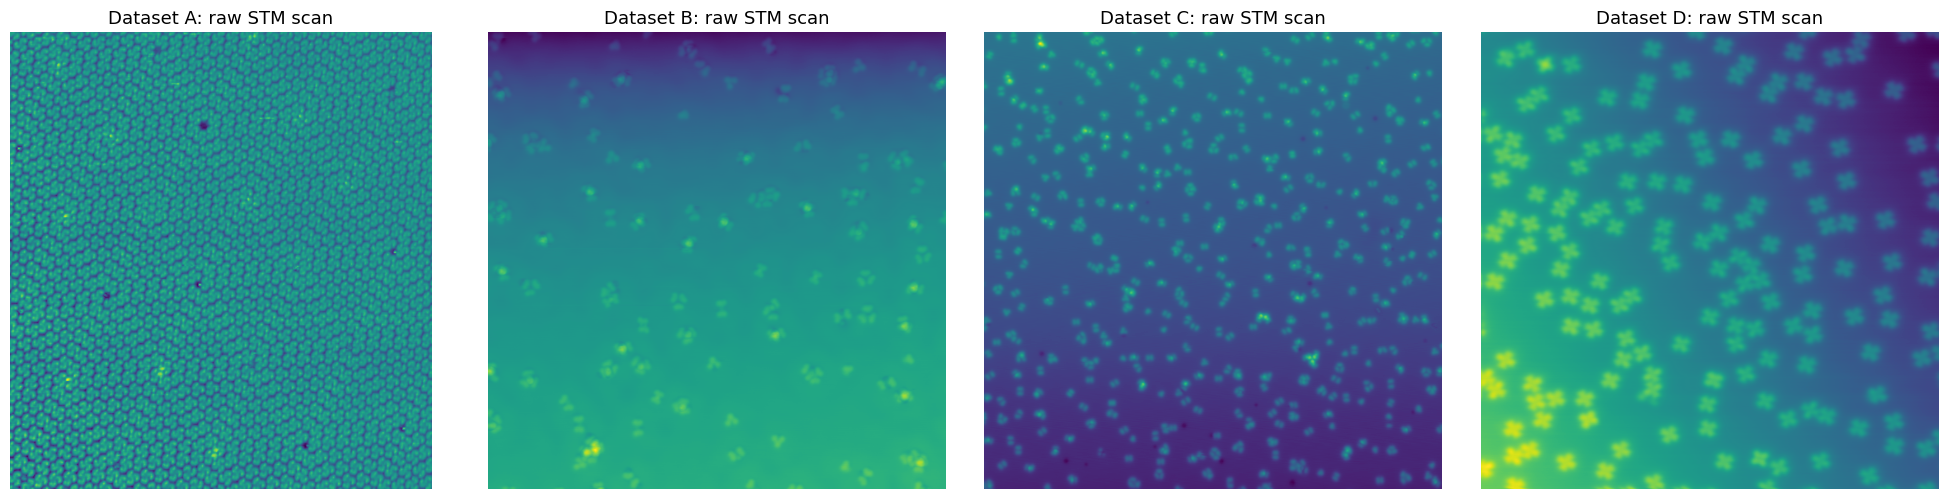

In [46]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, image, label in zip(axes, [image_a, image_b,image_c,image_d], ["Dataset A", "Dataset B","Dataset C","Dataset D"]):
    ax.imshow(image, cmap="viridis")
    ax.set_title(f"{label}: raw STM scan", fontsize=13)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. The mean-field artefact

STM images often have a slowly-varying intensity gradient across the scan, caused by tip drift, surface tilt, or thermal effects during acquisition. This gradient isn't part of the molecular signal we want to detect, and it disrupts thresholding-based binarisation later in the pipeline.

The plot below shows pixel intensity along three horizontal slices of an STM image. Notice how the mean shifts between slices, that's the artefact we need to remove.

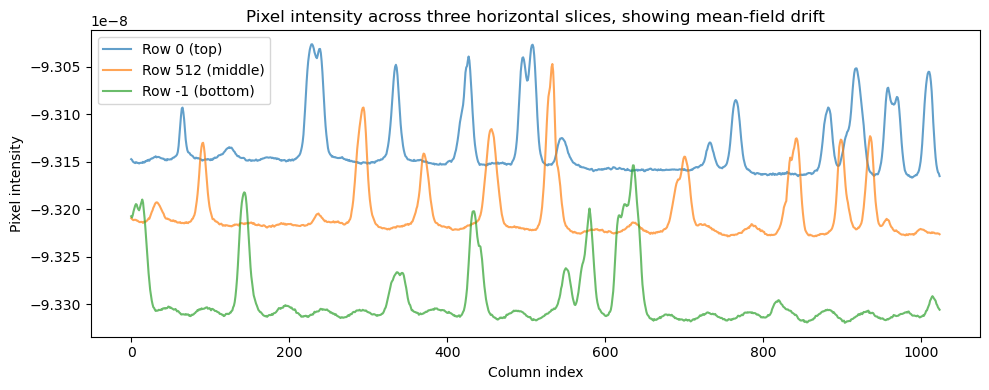

In [47]:
# Plot three horizontal slices through Dataset C to show the mean drift
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(image_c[0], label="Row 0 (top)", alpha=0.7)
ax.plot(image_c[image_c.shape[0] // 2], label=f"Row {image_c.shape[0] // 2} (middle)", alpha=0.7)
ax.plot(image_c[-1], label="Row -1 (bottom)", alpha=0.7)

ax.set_xlabel("Column index")
ax.set_ylabel("Pixel intensity")
ax.set_title("Pixel intensity across three horizontal slices, showing mean-field drift")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Mean-field removal

The fix is straightforward: subtract the per-row mean and the per-column mean from the image. This flattens the background while preserving local features (the molecules themselves).

In [48]:
def remove_mean_field(image):
    """Remove the slowly-varying mean-field artefact from an STM image.
    
    Subtracts the per-row mean and then the per-column mean. This flattens
    the background gradient while leaving local features (molecules) intact.
    
    Parameters
    ----------
    image : np.ndarray
        2D STM image array.
    
    Returns
    -------
    np.ndarray
        Mean-corrected image with flat background.
    """
    corrected = image.copy().astype(float)
    
    # Subtract the column-wise mean from each row
    col_means = np.mean(corrected, axis=0)
    corrected = corrected - col_means[np.newaxis, :]
    
    # Subtract the row-wise mean from each column
    row_means = np.mean(corrected, axis=1)
    corrected = corrected - row_means[:, np.newaxis]
    
    return corrected

## 7. Apply to all three datasets and verify

After mean-field removal, the row and column means should all be near zero across the image.

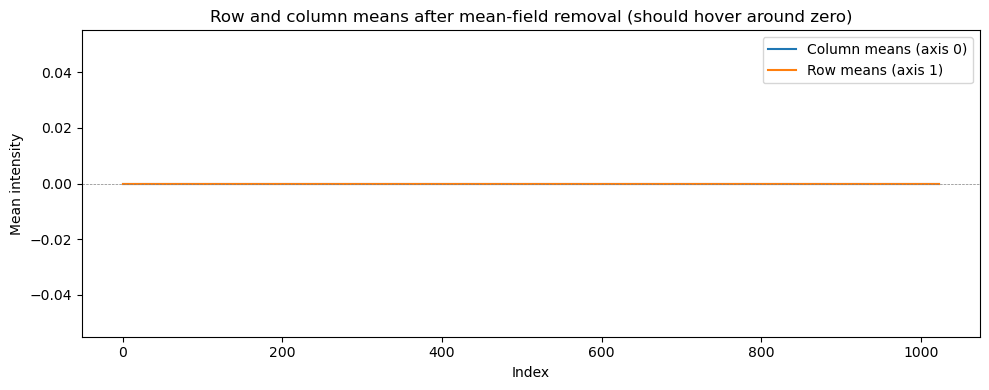

In [ ]:
# Apply mean-field removal to all three datasets
image_a_corrected = remove_mean_field(image_a)
image_b_corrected = remove_mean_field(image_b)
image_c_corrected = remove_mean_field(image_c)
image_d_corrected = remove_mean_field(image_d)

# Verify the means are now flat for Dataset C (same applies to A, D and B)
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(np.mean(image_c_corrected, axis=0), label="Column means (axis 0)")
ax.plot(np.mean(image_c_corrected, axis=1), label="Row means (axis 1)")
ax.axhline(0, color="grey", linestyle="--", linewidth=0.5)

ax.set_xlabel("Index")
ax.set_ylabel("Mean intensity")
ax.set_title("Row and column means after mean-field removal (should hover around zero)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Before-and-after comparison

The corrected images preserve molecular features but have a uniform background, ready for thresholding.

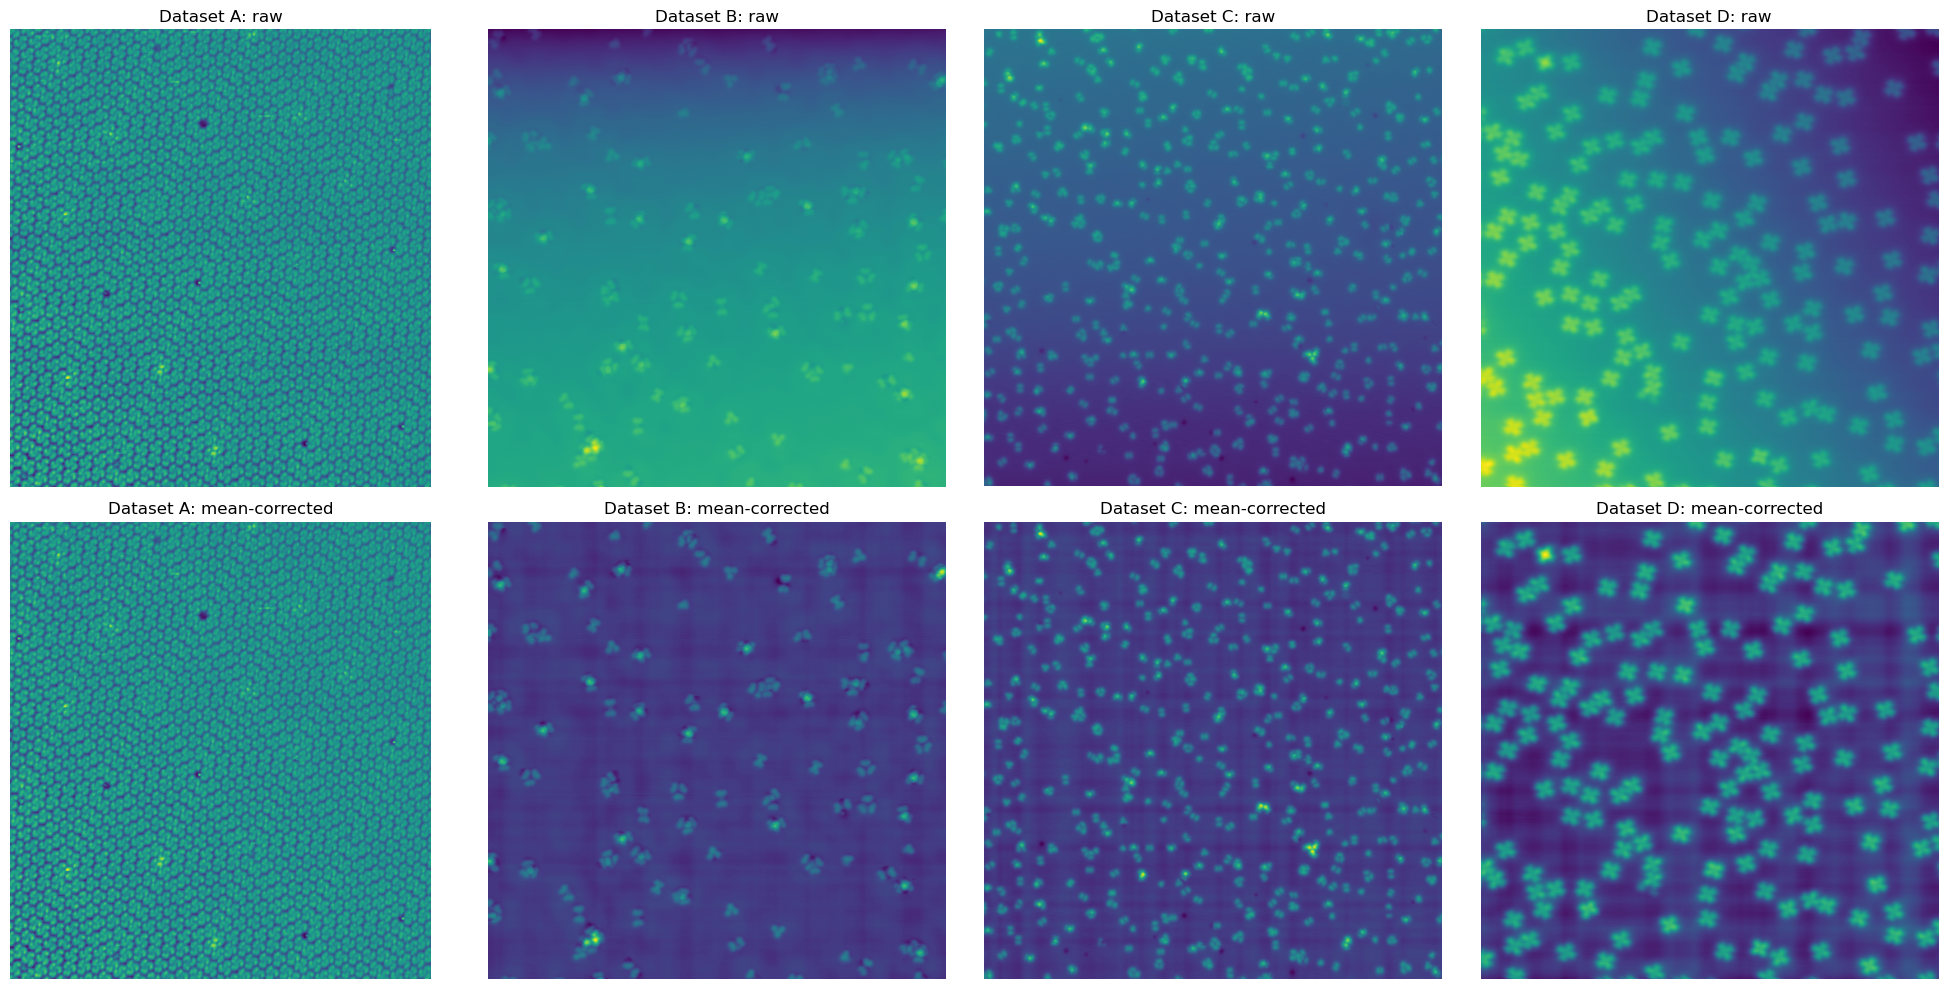

In [51]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Top row: raw images
for ax, image, label in zip(axes[0], [image_a, image_b, image_c, image_d], ["Dataset A", "Dataset B", "Dataset C","Dataset D"]):
    ax.imshow(image, cmap="viridis")
    ax.set_title(f"{label}: raw", fontsize=12)
    ax.axis("off")

# Bottom row: mean-corrected images
for ax, image, label in zip(axes[1], [image_a_corrected, image_b_corrected, image_c_corrected, image_d_corrected], ["Dataset A", "Dataset B", "Dataset C","Dataset D"]):
    ax.imshow(image, cmap="viridis")
    ax.set_title(f"{label}: mean-corrected", fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Summary

Three STM datasets, three file formats, one standardised pipeline:

1. **Format-specific loaders** abstract away `.txt`, `.p`, and `.sxm` differences. Each returns a 2D NumPy array.
2. **Mean-field removal** subtracts row-wise and column-wise means to flatten background gradients while preserving molecular features.
3. **Verification** confirms the corrected images have near-zero row and column means.

The corrected images are now ready for binarisation. See `02_binarization.ipynb` for the next stage.